# **GTI 771**

# **TP1**

## **Etape 0 : Importation du dataset**

In [ ]:
# ============================================================
# CONFIGURATION — adapter uniquement cette cellule
# ============================================================
import os, sys

# --- Détection automatique de l'environnement ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Dossier racine de tes données sur Google Drive
    BASE_DIR = '/content/drive/MyDrive/gti771/tp1'
    DATASET_DIR = '/content/dataset'
else:
    # Exécution locale : adapter ce chemin
    BASE_DIR = './data'
    DATASET_DIR = './data'

# --- Chemins dérivés (ne pas modifier) ---
CSV_PATH        = os.path.join(BASE_DIR, 'train_labels.csv')
ORIGINAL_TRAIN  = os.path.join(DATASET_DIR, 'original-train')
ORIGINAL_TEST   = os.path.join(DATASET_DIR, 'original-test')
CLEANED_TRAIN   = os.path.join(DATASET_DIR, 'data-cleaned', 'train')
CLEANED_TEST    = os.path.join(DATASET_DIR, 'data-cleaned', 'test')
PRE_TRAIN       = os.path.join(DATASET_DIR, 'data-cleaned-pre', 'train')
PRE_TEST        = os.path.join(DATASET_DIR, 'data-cleaned-pre', 'test')
REEQ_TRAIN      = os.path.join(DATASET_DIR, 'data-cleaned-pre-reeq', 'train')
OUT_H5_TRAIN    = os.path.join(BASE_DIR, 'data-cleaned-pre-train-glcm-zone4x4.h5')
OUT_H5_REEQ     = os.path.join(BASE_DIR, 'data-cleaned-pre-reeq-train-glcm-zone4x4.h5')
OUT_H5_TEST     = os.path.join(BASE_DIR, 'data-cleaned-pre-test-glcm-zone4x4.h5')

# Création des dossiers si besoin
for d in [CLEANED_TRAIN, CLEANED_TEST, PRE_TRAIN, PRE_TEST, REEQ_TRAIN]:
    os.makedirs(d, exist_ok=True)

print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"BASE_DIR : {BASE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction terminée avec succès !


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import numpy as np

# Chemins définis dans la cellule de configuration (plus haut)
csv_path = CSV_PATH
images_path = ORIGINAL_TRAIN

# Chargement uniquement du texte (très léger pour la RAM)
df_train = pd.read_csv(csv_path, sep=None, engine='python', names=['filename', 'emotion'])
df_train['filename'] = df_train['filename'].astype(str).str.strip()
df_train = df_train[df_train['filename'].str.startswith('train_')]

# Dictionnaire pour mapper les ID aux noms des émotions
labels_names = {1: 'Surprise', 2: 'Fear', 3: 'Disgust', 4: 'Happiness', 5: 'Sadness', 6: 'Anger', 7: 'Neutral'}

## **1a Visualisation des images de visages**

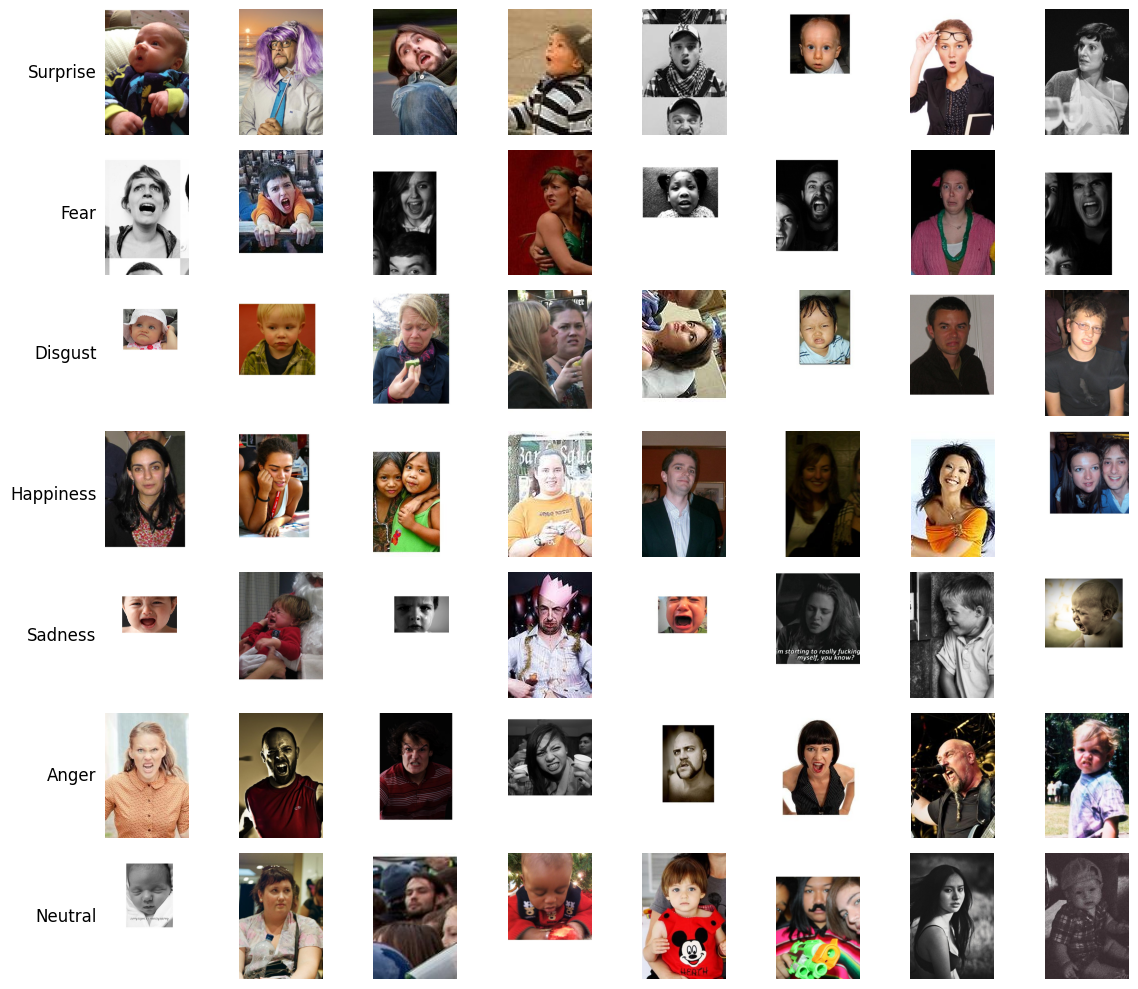

In [ ]:
def plot_grid_by_category(n, df, img_dir, labels_dict):
    fig, axes = plt.subplots(7, n, figsize=(12, 10))

    for label_id in range(1, 8):
        # On isole uniquement les lignes du CSV correspondant à l'émotion en cours
        subset = df[df['emotion'] == label_id]

        # Tirage de n images au hasard
        selected_rows = subset.sample(n=n, random_state=random.randint(0, 10000))

        for col, (_, row) in enumerate(selected_rows.iterrows()):
            img_file_path = os.path.join(img_dir, row['filename'])
            ax = axes[label_id - 1, col]

            # Lecture de l'image sur le disque uniquement au moment de l'afficher
            if os.path.exists(img_file_path):
                img = mpimg.imread(img_file_path)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, 'Erreur', ha='center')

            ax.axis('off')

            if col == 0:
                ax.text(-0.1, 0.5, labels_dict[label_id],
                        transform=ax.transAxes, va='center', ha='right', fontsize=12)

    plt.tight_layout()
    plt.show()

# Affichage de 8 colonnes
plot_grid_by_category(8, df_train, images_path, labels_names)

L'observation des images montre une forte variabilité au sein des classes de la base RAF-DB. Les images diffèrent notamment en termes de résolution, d’éclairage et de couleur (certaines sont en couleurs et d'autres en niveau de gris). On observe également plusieurs types d’occlusions, comme des mains ou des accessoires, ainsi que des angles de vue très différents. Ces variations montre l’importance d’un prétraitement afin d'en extraire les caractéristiques faciales essentielles.

## **1b Distribuition des données**

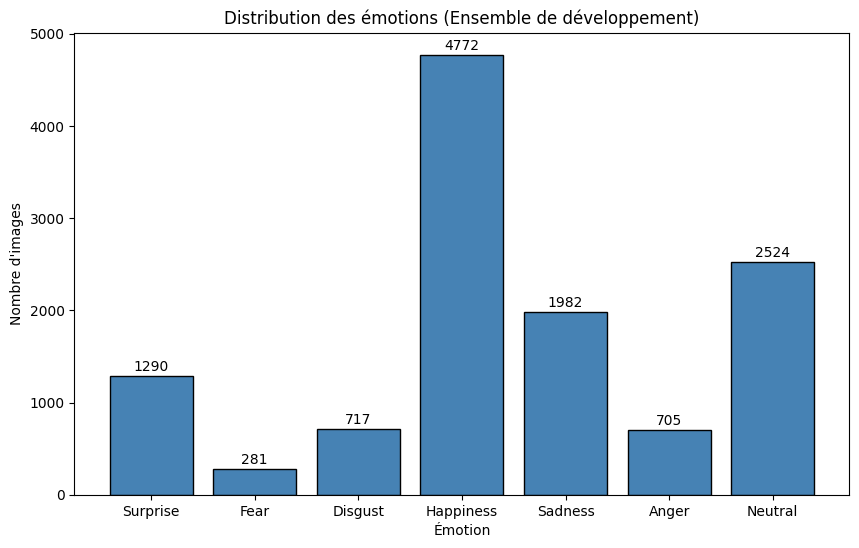

In [ ]:
def plot_class_distribution(df, labels_dict):
    # On compte les occurrences directement dans la colonne 'emotion' du DataFrame
    counts = [len(df[df['emotion'] == i]) for i in range(1, 8)]
    names = [labels_dict[i] for i in range(1, 8)]

    plt.figure(figsize=(10, 6))
    plt.bar(names, counts, color='steelblue', edgecolor='black')

    plt.title("Distribution des émotions (Ensemble de développement)")
    plt.xlabel("Émotion")
    plt.ylabel("Nombre d'images")

    for i, count in enumerate(counts):
        plt.text(i, count + 50, str(count), ha='center')

    plt.show()

plot_class_distribution(df_train, labels_names)

Non, l'ensemble de données est très déséquilibré. La classe “Happiness” (4) est largement dominante avec 4772 images, tandis que les classes "Fear" (2), "Disgust" (3) et "Anger" (6) sont très peu représentées, avec respectivement 281, 717 et 705 images.

## **1c Nettoyage de données**

In [ ]:
import os
import numpy as np
from skimage import io, color
from skimage.util import img_as_ubyte
import warnings
warnings.filterwarnings('ignore')

CLEANED_TRAIN_DIR = CLEANED_TRAIN
CLEANED_TEST_DIR = CLEANED_TEST
os.makedirs(CLEANED_TRAIN_DIR, exist_ok=True)
os.makedirs(CLEANED_TEST_DIR, exist_ok=True)

ORIGINAL_TRAIN_DIR = ORIGINAL_TRAIN
ORIGINAL_TEST_DIR = ORIGINAL_TEST

# --- PASSAGE 1 : Analyse statistique de l'ensemble d'entraînement ---
print("Étape 1 : Calcul des paramètres sur l'ensemble d'entraînement...")
train_files = [f for f in os.listdir(ORIGINAL_TRAIN_DIR) if f.endswith('.jpg')]
brightness_list = []

for filename in train_files:
    try:
        img = io.imread(os.path.join(ORIGINAL_TRAIN_DIR, filename))
        brightness_list.append(np.mean(img))
    except:
        pass

GLOBAL_MEAN = np.mean(brightness_list)
GLOBAL_STD = np.std(brightness_list)
print(f"-> Luminosité Moyenne : {GLOBAL_MEAN:.2f}, Écart-type : {GLOBAL_STD:.2f}")

# --- PASSAGE 2 : Nettoyage ---
def clean_dataset(input_dir, output_dir, mean_b, std_b):
    stats = {'total': 0, 'corrupted': 0, 'too_small': 0, 'bad_ratio': 0, 'outliers': 0, 'fixed_rgb': 0, 'saved': 0}
    files = [f for f in os.listdir(input_dir) if f.endswith('.jpg')]
    stats['total'] = len(files)

    for filename in files:
        img_path = os.path.join(input_dir, filename)
        out_path = os.path.join(output_dir, filename)

        # 1. Corruption
        try:
            img = io.imread(img_path)
        except Exception:
            stats['corrupted'] += 1
            continue

        # 2. Règles métier : Résolution et Ratio
        h, w = img.shape[0], img.shape[1]
        if h < 40 or w < 40:
            stats['too_small'] += 1
            continue

        ratio = w / h
        if ratio < 0.6 or ratio > 1.6:
            stats['bad_ratio'] += 1
            continue

        # 3. Statistiques : Outliers d'illumination (2.5 sigmas)
        brightness = np.mean(img)
        if abs(brightness - mean_b) > (2.5 * std_b):
            stats['outliers'] += 1
            continue

        # Sauvegarde
        io.imsave(out_path, img, check_contrast=False)
        stats['saved'] += 1

    return stats

print("\nÉtape 2 : Nettoyage en cours...")
train_stats = clean_dataset(ORIGINAL_TRAIN_DIR, CLEANED_TRAIN_DIR, GLOBAL_MEAN, GLOBAL_STD)
test_stats = clean_dataset(ORIGINAL_TEST_DIR, CLEANED_TEST_DIR, GLOBAL_MEAN, GLOBAL_STD)

print("\n--- RÉSULTATS ENTRAÎNEMENT ---")
print(train_stats)
print("\n--- RÉSULTATS TEST ---")
print(test_stats)

Étape 1 : Calcul des paramètres sur l'ensemble d'entraînement...
-> Luminosité Moyenne : 141.38, Écart-type : 46.70

Étape 2 : Nettoyage en cours...

--- RÉSULTATS ENTRAÎNEMENT ---
{'total': 12271, 'corrupted': 0, 'too_small': 3, 'bad_ratio': 0, 'outliers': 14, 'fixed_rgb': 0, 'saved': 12254}

--- RÉSULTATS TEST ---
{'total': 3068, 'corrupted': 0, 'too_small': 1, 'bad_ratio': 0, 'outliers': 3, 'fixed_rgb': 0, 'saved': 3064}


### Documentation du processus de nettoyage

Un algorithme de nettoyage en deux étapes a été conçu pour identifier des anomalies géométriques et statistiques.
1. **Règles métier (Détection) :** Les images avec une résolution inférieure à 40x40 pixels sont supprimées, car elles ne contiennent pas assez de données pour l'extraction de traits faciaux. Les images présentant un ratio d'aspect aberrant (< 0.6 ou > 1.6) sont également rejetées pour éviter les visages écrasés ou mal détourés.
2. **Méthodes statistiques (Détection) :** Un premier passage sur l'ensemble de développement a permis de calculer la moyenne et l'écart-type ($\sigma$) globaux de luminosité. Toute image dont l'intensité moyenne dévie de plus de $2.5\sigma$ est considérée comme aberrante (image surexposée ou sous-exposée).
3. **Gestion de l'ensemble de test :** Afin de ne pas divulguer d'informations, la moyenne et l'écart-type de luminosité ont été calculés exclusivement sur l'ensemble de développement. Ces deux paramètres fixes ont ensuite été passés à la fonction lors du nettoyage de l'ensemble de test pour préserver son intégrité.


### Tableau récapitulatif du nettoyage

| Étape / Problème | Ensemble de développement (Train) | Ensemble de test (Test) |
| :--- | :---: | :---: |
| **Total d'images initiales** | 12 271 | 3 068 |
| **Fichiers corrompus (rejetés)** | 0 | 0 |
| **Résolution insuffisante (< 40x40)** | 3 | 1 |
| **Ratio d'aspect aberrant** |0|0|
| **Outliers de luminosité (rejetées)** | 14 | 3 |
| **Total d'images propres sauvées** | **12 254** | **3 064** |

## **1d Prétraitement des images**

In [ ]:
import os
import cv2
import concurrent.futures
import warnings
warnings.filterwarnings('ignore')

CLEANED_TRAIN_DIR = CLEANED_TRAIN
CLEANED_TEST_DIR = CLEANED_TEST

PRE_TRAIN_DIR = PRE_TRAIN
PRE_TEST_DIR = PRE_TEST
os.makedirs(PRE_TRAIN_DIR, exist_ok=True)
os.makedirs(PRE_TEST_DIR, exist_ok=True)

# Initialisation de l'objet CLAHE (2.5 est un équivalent approximatif au clip_limit=0.03 de skimage)
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))

def process_single_image_cv2(args):
    img_path, out_path = args

    # 1. Lecture de l'image (chargée par défaut en BGR par OpenCV)
    img = cv2.imread(img_path)
    if img is None:
        return

    # 2. Redimensionnement optimisé avec interpolation de zone (idéal pour la réduction)
    img_resized = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)

    # 3. Application du CLAHE
    # OpenCV nécessite d'appliquer le CLAHE sur le canal de luminance (L) de l'espace LAB
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    cl = clahe.apply(l)

    # Fusion des canaux et retour en BGR pour la sauvegarde
    limg = cv2.merge((cl, a, b))
    img_eq = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # 4. Sauvegarde rapide
    cv2.imwrite(out_path, img_eq)

def preprocess_images_parallel_cv2(input_dir, output_dir):
    files = [f for f in os.listdir(input_dir) if f.endswith('.jpg')]
    tasks = [(os.path.join(input_dir, f), os.path.join(output_dir, f)) for f in files]

    # Limitation stricte aux cœurs disponibles sur Colab pour éviter le surcoût de contexte
    max_workers = os.cpu_count() or 2

    with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count() or 2) as executor:
        executor.map(process_single_image_cv2, tasks)

print("Prétraitement de l'ensemble d'entraînement en parallèle...")
preprocess_images_parallel_cv2(CLEANED_TRAIN_DIR, PRE_TRAIN_DIR)

print("Prétraitement de l'ensemble de test en parallèle...")
preprocess_images_parallel_cv2(CLEANED_TEST_DIR, PRE_TEST_DIR)

print("Génération des jeux de données data-cleaned-pre terminée.")

Prétraitement de l'ensemble d'entraînement en parallèle...
Prétraitement de l'ensemble de test en parallèle...
Génération des jeux de données data-cleaned-pre terminée.


### Justification des prétraitements appliqués

Deux algorithmes de prétraitement ont été combinés pour réduire la variabilité intra-classe :
*   **Normalisation de la résolution (128x128 pixels)** : Les images de la base RAF-DB possèdent des dimensions hétérogènes. Les modèles d'apprentissage profond nécessitant des tenseurs d'entrée de taille fixe, cette étape unifie la géométrie des données.
*   **Normalisation du contraste (CLAHE)** : Les conditions d'illumination "in-the-wild" introduisent un bruit important. L'égalisation adaptative d'histogramme (CLAHE) atténue les ombres sévères et rehausse les contours des traits faciaux, facilitant l'extraction des caractéristiques liées aux émotions.

**Gestion de la fuite d'information (Data Leakage) :**
Pour éviter d'introduire des informations de l'ensemble de test dans le processus, le choix s'est porté sur des algorithmes strictement *intra-image* (locaux). La normalisation globale (ex: centrage-réduction standardisé) nécessiterait de calculer la moyenne et l'écart-type des pixels sur l'ensemble de développement, puis d'appliquer ces scalaires à l'ensemble de test pour préserver son caractère "inconnu". En utilisant le CLAHE et le redimensionnement spatial, le calcul mathématique dépend uniquement des pixels de l'image traitée. L'ensemble de test peut donc subir le même pipeline de manière totalement isolée, annulant structurellement tout risque de fuite de données.

## **1e Rééquilibrage des données**

### Méthode d'équilibrage : Sur-échantillonnage par augmentation de données (Data Augmentation)

**Justification du choix :**
Le sous-échantillonnage aléatoire a été écarté car il entraîne une perte massive d'informations précieuses, ce qui est critique pour l'apprentissage profond. Le sur-échantillonnage aléatoire simple (copie exacte) a également été évité car il favorise le surapprentissage (overfitting).

La méthode privilégiée est l'**augmentation de données par transformations géométriques** ciblée sur les classes minoritaires. En appliquant des retournements horizontaux (symétrie naturelle du visage) et des rotations légères (simulant l'inclinaison de la tête), nous créons des échantillons synthétiques, diversifiés et plausibles. Cette approche permet d'atteindre l'équilibre quantitatif tout en forçant le modèle à apprendre des caractéristiques invariantes à la rotation et à l'orientation.

Conformément aux bonnes pratiques, cette méthode est appliquée **uniquement à l'ensemble de développement** pour préserver l'intégrité de l'ensemble de test.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from skimage import io, transform
from skimage.util import img_as_ubyte
import concurrent.futures
import warnings
warnings.filterwarnings('ignore')

PRE_TRAIN_DIR = PRE_TRAIN
REEQ_TRAIN_DIR = REEQ_TRAIN
os.makedirs(REEQ_TRAIN_DIR, exist_ok=True)

# 1. Copie instantanée via le système d'exploitation
print("Copie des fichiers existants...")
os.system(f"cp -r {PRE_TRAIN_DIR}/* {REEQ_TRAIN_DIR}/")

csv_path = CSV_PATH
df = pd.read_csv(csv_path, sep=None, engine='python', names=['filename', 'emotion'])
df['filename'] = df['filename'].astype(str).str.strip()

existing_files = set(os.listdir(PRE_TRAIN_DIR))
df_pre = df[df['filename'].isin(existing_files)].copy()

class_counts = df_pre['emotion'].value_counts().to_dict()
max_count = max(class_counts.values())

# 2. Fonction isolée traitant une seule image (nécessaire pour le multiprocessing)
def generate_single_image(args):
    base_path, new_name = args
    img = io.imread(base_path)

    if random.random() > 0.5:
        img = np.fliplr(img)

    angle = random.uniform(-15, 15)
    img_aug = transform.rotate(img, angle, mode='edge')

    out_path = os.path.join(REEQ_TRAIN_DIR, new_name)
    io.imsave(out_path, img_as_ubyte(img_aug), check_contrast=False)
    return new_name

# 3. Préparation du registre des tâches
tasks = []
new_augmented_files = []

for emotion_id in range(1, 8):
    current_count = class_counts.get(emotion_id, 0)
    deficit = max_count - current_count

    if deficit > 0:
        class_images = df_pre[df_pre['emotion'] == emotion_id]['filename'].tolist()
        for i in range(deficit):
            base_img_name = random.choice(class_images)
            base_img_path = os.path.join(PRE_TRAIN_DIR, base_img_name)
            new_filename = f"{base_img_name.split('.')[0]}_aug_{i}-ree.jpg"

            tasks.append((base_img_path, new_filename))
            new_augmented_files.append({'filename': new_filename, 'emotion': emotion_id})

# 4. Lancement de la génération en parallèle
print(f"Classe majoritaire : {max_count}. Génération de {len(tasks)} images en parallèle...")
with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count() or 2) as executor:
    executor.map(generate_single_image, tasks)

df_reeq = pd.concat([df_pre, pd.DataFrame(new_augmented_files)], ignore_index=True)
print("Rééquilibrage terminé ! Nombre total d'images :", len(df_reeq))

Copie des fichiers existants...
Classe majoritaire : 4767. Génération de 21115 images en parallèle...
Rééquilibrage terminé ! Nombre total d'images : 33369



--- GRILLE DES IMAGES AJOUTÉES ---


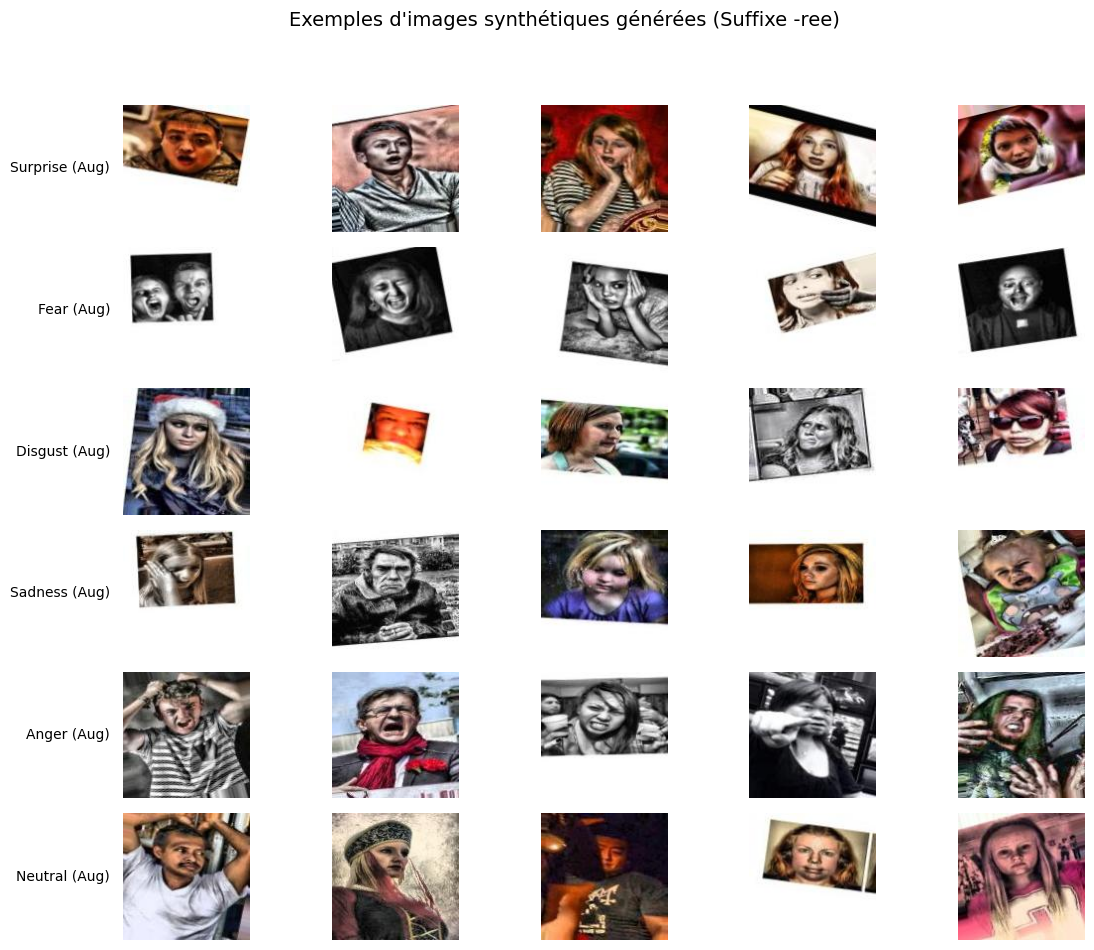


--- NOUVELLE DISTRIBUTION ---


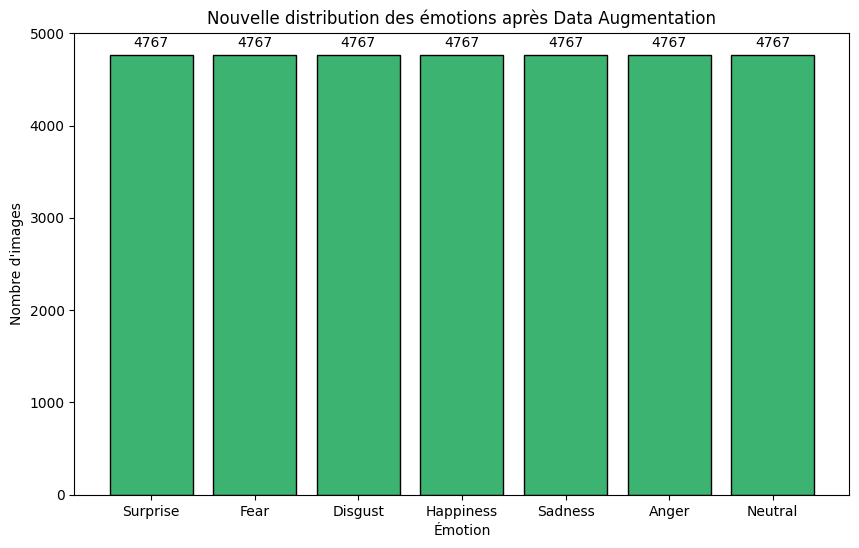

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

labels_names = {1: 'Surprise', 2: 'Fear', 3: 'Disgust', 4: 'Happiness', 5: 'Sadness', 6: 'Anger', 7: 'Neutral'}
df_new_only = pd.DataFrame(new_augmented_files)

# --- A. Affichage de la grille des NOUVELLES images ---
def plot_augmented_grid(n, df_new, img_dir, labels_dict):
    # On filtre les émotions qui ont effectivement reçu de nouvelles images
    emotions_augmented = df_new['emotion'].unique()
    num_rows = len(emotions_augmented)

    if num_rows == 0:
        print("Aucune image ajoutée (dataset déjà équilibré).")
        return

    fig, axes = plt.subplots(num_rows, n, figsize=(12, 1.5 * num_rows))

    # Si une seule classe a été augmentée, axes n'est pas en 2D, on le force
    if num_rows == 1: axes = [axes]

    for row_idx, emotion_id in enumerate(sorted(emotions_augmented)):
        subset = df_new[df_new['emotion'] == emotion_id]
        # Prendre n images (ou moins si on n'en a pas généré n)
        n_samples = min(n, len(subset))
        selected_rows = subset.sample(n=n_samples, random_state=42)

        for col_idx, (_, row) in enumerate(selected_rows.iterrows()):
            img_path = os.path.join(img_dir, row['filename'])
            ax = axes[row_idx][col_idx] if num_rows > 1 else axes[col_idx]

            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis('off')

            if col_idx == 0:
                ax.text(-0.1, 0.5, f"{labels_dict[emotion_id]} (Aug)",
                        transform=ax.transAxes, va='center', ha='right', fontsize=10)

    plt.suptitle("Exemples d'images synthétiques générées (Suffixe -ree)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

print("\n--- GRILLE DES IMAGES AJOUTÉES ---")
plot_augmented_grid(5, df_new_only, REEQ_TRAIN_DIR, labels_names)

# --- B. Affichage du nouvel histogramme ---
def plot_balanced_distribution(df, labels_dict):
    counts = [len(df[df['emotion'] == i]) for i in range(1, 8)]
    names = [labels_dict[i] for i in range(1, 8)]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, counts, color='mediumseagreen', edgecolor='black')

    plt.title("Nouvelle distribution des émotions après Data Augmentation")
    plt.xlabel("Émotion")
    plt.ylabel("Nombre d'images")

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom')

    plt.show()

print("\n--- NOUVELLE DISTRIBUTION ---")
plot_balanced_distribution(df_reeq, labels_names)

## **1f : Analyse de l'algorithme GLCM (Approche Locale)**

**Approche choisie : Locale.** Cette approche est privilégiée car elle permet de capturer les détails fins des régions spécifiques du visage (yeux, bouche) qui sont responsables des micro-expressions faciales, tout en limitant l'impact des variations d'éclairage globales

**Algorithme choisi :** GLCM (Gray-Level Co-occurrence Matrix) et propriétés de Haralick

**Étude de l'algorithme :**

* Entrée : L'algorithme exige strictement des images en niveaux de gris (2D) discrétisées sur un nombre défini de niveaux (souvent 256). Une normalisation géométrique (toutes les images à la même taille, ex: 128x128) est indispensable pour que le découpage en zones soit cohérent d'une image à l'autre

* Principe : La GLCM quantifie la texture en examinant la relation spatiale entre les pixels. Elle calcule la fréquence à laquelle une paire de pixels avec des valeurs de gris spécifiques apparaît dans l'image selon une distance et un angle donnés. Des mesures statistiques (moments de Haralick) sont ensuite extraites de cette matrice pour décrire la texture (contraste, homogénéité, énergie, etc.)

* Hyperparamètres :

  * Distances ($d$) : L'espacement en pixels entre la paire de pixels analysée

  * Angles ($\theta$) : Les directions d'analyse (généralement $0, \pi/4, \pi/2, 3\pi/4$ radians pour capturer toutes les orientations)

  * Niveaux de gris : Le niveau de quantification de l'image (ex: réduction à 16 ou 32 niveaux pour réduire le bruit et la taille de la matrice)

* Vecteur de sortie : Un vecteur 1D de variables continues (flottants). La dimension dépend du nombre de propriétés calculées multiplié par le nombre d'angles

* Bibliothèque : scikit-image (via les modules skimage.feature.graycomatrix et skimage.feature.graycoprops)

## **1g : Extraction de primitives locales (Zonage)**

1. Définition de la grille de zones :

* Dimension : Grille de $4 \times 4$ (soit $n=16$ zones). Les images prétraitées faisant 128x128 pixels, chaque zone mesurera exactement $32 \times 32$ pixels

* Principe du zonage : L'image est découpée sous forme de damier. Cette méthode permet d'isoler approximativement les zones sémantiques clés du visage (la rangée du haut pour les sourcils/yeux, la rangée du bas pour la bouche) sans nécessiter un détecteur de points de repères complexe

* Hyperparamètre clé : La taille de la grille (ici $4 \times 4$). Une grille trop fine (ex: $16 \times 16$) générerait un vecteur beaucoup trop grand et capturerait du bruit, tandis qu'une grille trop large ($2 \times 2$) perdrait la capacité à isoler les traits faciaux

2. Extraction et Concaténation (Nature du vecteur) :

* Pour chaque zone de 32x32, la GLCM calcule 5 propriétés de Haralick (Contraste, Dissimilarité, Homogénéité, Énergie, Corrélation) sur 4 angles différents, soit $5 \times 4 = 20$ caractéristiques par zone

* Vecteur global : En concaténant les 16 zones, nous obtenons un vecteur final de $16 \times 20 = \textbf{320 dimensions}$ par image. Il s'agit d'un vecteur de type flottant continu

In [ ]:
import os
import numpy as np
import pandas as pd
import h5py
from skimage import io, color
from skimage.feature import graycomatrix, graycoprops
import concurrent.futures
import warnings
warnings.filterwarnings('ignore')

# Définition des paramètres
GRID_SIZE = 4
PROPERTIES = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
DISTANCES = [1]

def extract_glcm_local(image):
    """
    Découpe l'image en zones et extrait les caractéristiques GLCM pour chaque zone.
    """
    if len(image.shape) == 3:
        image = color.rgb2gray(image)

    image_quantized = (image * 31).astype(np.uint8)
    h, w = image_quantized.shape
    zone_h, zone_w = h // GRID_SIZE, w // GRID_SIZE

    global_feature_vector = []

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            zone = image_quantized[i*zone_h : (i+1)*zone_h, j*zone_w : (j+1)*zone_w]
            glcm = graycomatrix(zone, distances=DISTANCES, angles=ANGLES,
                                levels=32, symmetric=True, normed=True)
            zone_features = []
            for prop in PROPERTIES:
                zone_features.extend(graycoprops(glcm, prop).flatten())
            global_feature_vector.extend(zone_features)

    return np.array(global_feature_vector, dtype=np.float32)

# --- NOUVELLES FONCTIONS WORKER POUR LE MULTIPROCESSING ---

def process_single_train_glcm(args):
    """Charge une image d'entraînement et extrait les features GLCM."""
    img_path, emotion_label = args
    try:
        img = io.imread(img_path)
        features = extract_glcm_local(img)
        return features, emotion_label
    except Exception:
        return None, None

def process_single_test_glcm(img_path):
    """Charge une image de test, extrait les features et retourne le nom du fichier."""
    try:
        img = io.imread(img_path)
        features = extract_glcm_local(img)
        filename = os.path.basename(img_path).encode('utf-8')
        return features, filename
    except Exception:
        return None, None

# --- FONCTIONS PRINCIPALES OPTIMISÉES ---

def process_and_save_features_optimized(images_dir, labels_df, output_h5_file):
    """
    Itère sur les images, extrait les vecteurs en parallèle, et sauvegarde en HDF5.
    """
    print(f"Extraction des primitives pour : {output_h5_file}")

    # Optimisation 1 : Dictionnaire pour une recherche d'étiquette en O(1)
    labels_dict = dict(zip(labels_df['filename'], labels_df['emotion']))

    # Préparation de la liste des tâches
    tasks = []
    for filename in os.listdir(images_dir):
        if filename.endswith('.jpg'):
            base_name = filename.split('_aug')[0] + '.jpg' if '_aug' in filename else filename
            if base_name in labels_dict:
                img_path = os.path.join(images_dir, filename)
                tasks.append((img_path, labels_dict[base_name]))

    features_list = []
    labels_list = []

    # Optimisation 2 : Calcul vectoriel distribué
    with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count() or 2) as executor:
        results = executor.map(process_single_train_glcm, tasks)

        for features, label in results:
            if features is not None:
                features_list.append(features)
                labels_list.append(label)

    # Sauvegarde au format HDF5
    X = np.array(features_list)
    y = np.array(labels_list)

    with h5py.File(output_h5_file, 'w') as hf:
        hf.create_dataset('features', data=X)
        hf.create_dataset('labels', data=y)

    print(f"-> Fichier généré avec succès ! Shape X: {X.shape}, Shape y: {y.shape}")


def process_and_save_test_features_optimized(images_dir, output_h5_file):
    """
    Extrait les vecteurs de l'ensemble de test en parallèle et sauvegarde en HDF5.
    """
    print(f"Extraction des primitives (TEST) pour : {output_h5_file}")

    # Préparation de la liste des chemins
    img_paths = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.jpg')]

    features_list = []
    filenames_list = []

    # Optimisation Multiprocessing
    with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count() or 2) as executor:
        results = executor.map(process_single_test_glcm, img_paths)

        for features, fname in results:
            if features is not None:
                features_list.append(features)
                filenames_list.append(fname)

    # Sauvegarde HDF5 spéciale test
    X = np.array(features_list)
    f_names = np.array(filenames_list)

    with h5py.File(output_h5_file, 'w') as hf:
        hf.create_dataset('features', data=X)
        hf.create_dataset('filenames', data=f_names)

    print(f"-> Fichier de TEST généré avec succès ! Shape X: {X.shape}, Fichiers: {f_names.shape}")

# --- EXÉCUTION ---
DIR_PRE_TRAIN = PRE_TRAIN
DIR_PRE_REEQ = REEQ_TRAIN
DIR_PRE_TEST = PRE_TEST

OUT_TRAIN = 'data-cleaned-pre-train-glcm-zone4x4.h5'
OUT_REEQ = 'data-cleaned-pre-reeq-train-glcm-zone4x4.h5'
OUT_TEST = 'data-cleaned-pre-test-glcm-zone4x4.h5'

# Chargement des étiquettes d'entraînement
df_train = pd.read_csv(CSV_PATH, sep=None, engine='python', names=['filename', 'emotion'])
df_train['filename'] = df_train['filename'].astype(str).str.strip()

# Lancement des extractions optimisées
process_and_save_features_optimized(DIR_PRE_TRAIN, df_train, OUT_TRAIN)
process_and_save_features_optimized(DIR_PRE_REEQ, df_train, OUT_REEQ)
process_and_save_test_features_optimized(DIR_PRE_TEST, OUT_TEST)

Extraction des primitives pour : data-cleaned-pre-train-glcm-zone4x4.h5
-> Fichier généré avec succès ! Shape X: (12254, 320), Shape y: (12254,)
Extraction des primitives pour : data-cleaned-pre-reeq-train-glcm-zone4x4.h5
-> Fichier généré avec succès ! Shape X: (33369, 320), Shape y: (33369,)
Extraction des primitives (TEST) pour : data-cleaned-pre-test-glcm-zone4x4.h5
-> Fichier de TEST généré avec succès ! Shape X: (3064, 320), Fichiers: (3064,)


In [ ]:
import shutil

# Définition du dossier de destination sur Google Drive
drive_dest_dir = BASE_DIR

# Copie des fichiers
shutil.copy(OUT_TRAIN, drive_dest_dir)
shutil.copy(OUT_REEQ, drive_dest_dir)
shutil.copy(OUT_TEST, drive_dest_dir)

print("Les fichiers .h5 ont été copiés avec succès sur Google Drive.")

Les fichiers .h5 ont été copiés avec succès sur Google Drive.
